In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Nino12最大值: 4.56
Nino12最小值: -2.34
Nino12平均值: -0.11


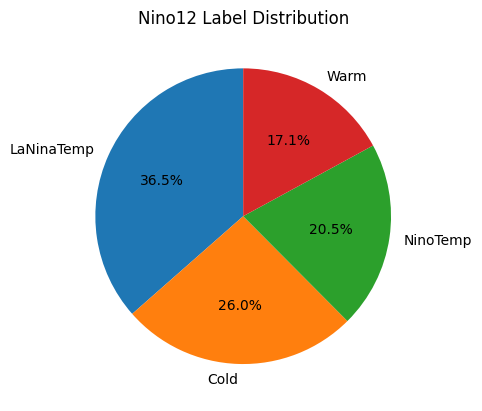

In [5]:
#第一问

df = pd.read_csv('11.nino12.long.anom.data.csv')
dates = []
for year in df['Year']:
    for month in range(1, 13):
        dates.append(f"{year}-{month:02d}-01")
df_melt = pd.melt(df, id_vars='Year', var_name='Month', value_name='Nino12')
df_melt['Date'] = dates
df_melt = df_melt[['Date', 'Nino12']]
df_clean = df_melt.dropna(subset=['Nino12'])
df_clean.to_csv('nino12_dropnan.txt', index=False, header=True)
#第二问
df = pd.read_csv('nino12_dropnan.txt')
nino12_max = df['Nino12'].max()
nino12_min = df['Nino12'].min()
nino12_mean = df['Nino12'].mean()
print(f"Nino12最大值: {nino12_max:.2f}")
print(f"Nino12最小值: {nino12_min:.2f}")
print(f"Nino12平均值: {nino12_mean:.2f}")
#第三问

df = pd.read_csv('nino12_dropnan.txt')
category = [df['Nino12'].min(), -0.5, 0, 0.5, df['Nino12'].max()]
labels = ['LaNinaTemp', 'Cold', 'Warm', 'NinoTemp']
df['Label'] = pd.cut(df['Nino12'], bins=category, labels=labels)
df.to_csv('nino12_dropnan_result.csv', index=False)
label_counts = df['Label'].value_counts()
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Nino12 Label Distribution')
plt.savefig('nino12_pie.png', dpi=300)
# plt.close()
plt.show()
#第四问
data = pd.read_csv('nino12_dropnan_result.csv')
LaNinaList = []
NinoList = []
for i in range(len(data) - 4):
    if all(data['Label'][i:i+5] == 'LaNinaTemp'):
        LaNinaList.append(data['Date'][i])
    if all(data['Label'][i:i+5] == 'NinoTemp'):
        NinoList.append(data['Date'][i])
with open('LaNinaStartDate.txt', 'w') as f:
    for date in LaNinaList:
        f.write(date + '\n')
with open('NinoStartDate.txt', 'w') as f:
    for date in NinoList:
        f.write(date + '\n')


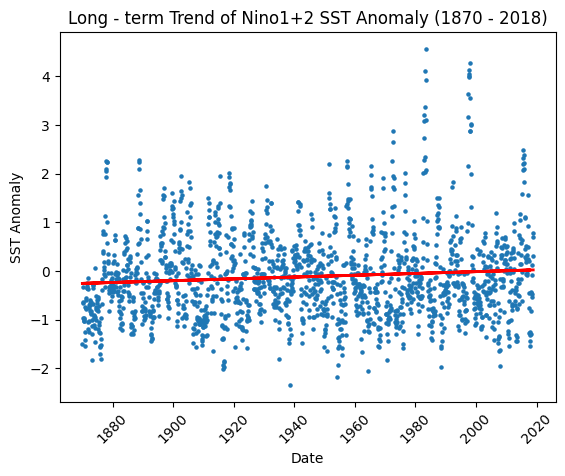

海温距平长期趋势斜率: 0.00015253678650389876


In [4]:
df = pd.read_csv('11.nino12.long.anom.data.csv')
df_melted = df.melt(id_vars=['Year'], var_name='Month', value_name='SST_Anomaly')
df_melted['Date'] = pd.to_datetime(df_melted['Year'].astype(str)+'-'+df_melted['Month']+'-01')
df_dropped = df_melted.dropna(subset=['SST_Anomaly'])
# 准备数据用于线性回归，将时间转换为数值（以月份为单位计数）
df_dropped['time_index'] = (df_dropped['Date'] - df_dropped['Date'].min()).dt.days // 30
X = df_dropped['time_index'].values.reshape(-1, 1)
y = df_dropped['SST_Anomaly'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.scatter(df_dropped['Date'], df_dropped['SST_Anomaly'], s=5)
plt.plot(df_dropped['Date'], y_pred, color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('SST Anomaly')
plt.title('Long - term Trend of Nino1+2 SST Anomaly (1870 - 2018)')
plt.xticks(rotation = 45)
plt.show()
print(f"海温距平长期趋势斜率: {model.coef_[0]}")